# Lecture 1 - Introduction to the Vacuum World

In this notebook we will introduce the concept of `environment`, `agent` and we will try to compare a `random_agent` against a simple `reflex agent`.

## Environment

### The Vacuum World

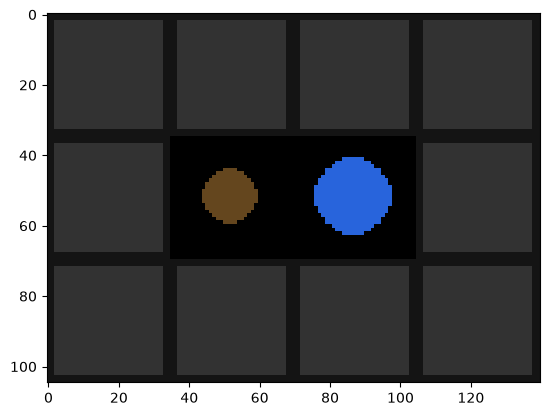

In [28]:
env = VacuumWorld(render_mode=RenderMode.RGB_ARRAY, observation_type=ObservationType.IMAGE, difficulty=0)
frame = env._get_obs()

from matplotlib import pyplot as plt

plt.imshow(frame)
plt.show()

In [27]:
from scripts.runner import human_testing

env = VacuumWorld(difficulty=0)
human_testing(env)

An agent, as defined in chapter 2.1 of the *Artificial Intelligence: A Modern Approach* book, is anything that can perceive its environment through sensors, and act upon that environment through actuators based on its agent program. This can be a dog, a robot, or even you. As long as you can perceive the environment and act on it, you are an agent. This notebook will explain how to implement a simple agent, create an environment, and implement a program that helps the agent act on the environment based on its percepts.

We will use object of the class `Agent`. Let's import it.

A random agent program, as the name suggests, chooses an action at random, without taking into account the percepts.\
Here, we will demonstrate a random vacuum agent for a trivial vacuum environment, that is, the two-state environment.

So, what does our `RandomAgent` do?\
Well pretty much it initializes itself by taking down the possible actions (all) and once it has to act it just acts randomly.

Don't be scared by the `gym.Env`: in this serie of notebooks we will use the **Gymnasium Protocol**, a well established protocol to deal with agents (especially in Reinforcement Learning Scenarios, but we will adapt it). You can find more about it in [this documentation here](https://gymnasium.farama.org/introduction/basic_usage/).

So don't bother it and let's see the agent in action!

We will render the scene with PyGame. Personally I find it really enjoyable, maybe look at its [documentation here](https://www.pygame.org/docs/).

### Simple Reflex Agent

In [43]:
# TODO implement your 
import numpy as np
class ReflexAgent(Agent):
    def __init__(self, env):
        self.action_space = env.action_space

    def act(self, observation):
        vacuum_position = np.argwhere(observation == 3)[0]
        dirt_positions = np.argwhere(observation == 1)

        if len(dirt_positions) == 0:
            return 5  # SUCK

        dirt_position = dirt_positions[0]

        if dirt_position[0] < vacuum_position[0]:
            return 0  # UP

        if dirt_position[0] > vacuum_position[0]:
            return 1  # DOWN

        if dirt_position[1] < vacuum_position[1]:
            return 2  # LEFT

        if dirt_position[1] > vacuum_position[1]:
            return 3  # RIGHT

        return 5  # SUCK

In [55]:
env = VacuumWorld(difficulty=0)
agent = ReflexAgent(env)
run_episode(env, agent)

110.0

In [56]:
env = VacuumWorld(difficulty=1)
agent = ReflexAgent(env)
run_episode(env, agent)

-1794.2